# Day 30: Tümleşik Halı Tasarım ve Görsel Analiz Hattı

Bu not defteri, Day 28'de geliştirilen metin tabanlı halı deseni üretim modeli ile Day 29'da oluşturulan görsel analiz modüllerinin tek bir uygulama altında nasıl birleştirildiğini göstermektedir.

> **Merinos Halı Sanayi ve Ticaret A.Ş. — Endüstriyel Yapay Zekâ Stajı (Faz 5 Capstone)**  
> **Staj Defteri Karşılığı:** Yaprak 59 & Yaprak 60 (Şekil 59 & Şekil 60)  
> **Yazar:** Seydi Eryılmaz (@seydivakkas) | Telif Hakkı (c) 2026. TÜM HAKLAR SAKLIDIR.

In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt

print("Merinos Industrial AI - Day 30")

Merinos Industrial AI - Day 30


### 1. Pipeline yapılandırmasını yükleme

In [2]:
import json

config_path = "mini_project/configs/pipeline_config.json"
with open(config_path, "r", encoding="utf-8") as f:
    config = json.load(f)

print("Konfigürasyon yüklendi.")
print("Üretim modeli:", config.get("generation", {}))

Konfigürasyon yüklendi.
Üretim modeli: {'model': 'sdxl', 'steps': 30, 'guidance_scale': 7.5}


### 2. Örnek tasarım brief'ini yükleme

In [3]:
brief_path = "mini_project/fixtures/sample_design_briefs.json"
with open(brief_path, "r", encoding="utf-8") as f:
    briefs = json.load(f)

sample_brief = briefs[0]
print(f"Yüklenen Tasarım Brief ID: {sample_brief['brief_id']}")
print(f"Başlık : {sample_brief['title']}")
print(f"Stil   : {sample_brief['style']}")
print(f"Motif  : {sample_brief['motif']}")
print(f"Renkler: {sample_brief['primary_color']} & {sample_brief['secondary_color']}")

Yüklenen Tasarım Brief ID: BRF-CLS-01
Başlık : Osmanlı Saray Koleksiyonu Madalyon Halı
Stil   : Klasik Osmanlı
Motif  : Merkezi Barok Madalyon ve Kıvrık Rumi Dalları
Renkler: Krem & Osmanlı Kırmızısı ve Altın Varak


### 3. Tümleşik Halı Tasarım & Görsel Analiz Hattının Başlatılması ve İstem Montajı (Yaprak 59)
Staj Defteri Yaprak 59 uyarınca; serbest metin yerine kullanıcı girdisi yapısal alanlara ayrıştırılır. Zorunlu alanlar (`style`, `motif`, `primary_color`) Pydantic v2 ile doğrulanır; isteğe bağlı alanlar boş bırakıldığında prompt'a eklenmez.

In [4]:
import sys
from pathlib import Path

# Dinamik proje kök dizini ekleme
CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name.startswith("day") else CURRENT_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from day30.mini_project.src.pipeline import IntegratedCarpetPipeline
from day30.mini_project.src.models import CarpetDesignInput, SymmetryMode

pipeline = IntegratedCarpetPipeline(config_path="mini_project/configs/pipeline_config.json")
brief_input = CarpetDesignInput(**sample_brief)
prompt_res = pipeline.assemble_prompt(brief_input)

print("--- YAPRAK 59 İSTEM MONTAJI SONUCU ---")
print(f"Pozitif İstem : {prompt_res.assembled_prompt}")
print(f"Negatif İstem : {prompt_res.negative_prompt}")
print(f"Dahil Edilen  : {list(prompt_res.included_fields.keys())}")
print(f"Boş Bırakılan : {prompt_res.omitted_fields}")

--- YAPRAK 59 İSTEM MONTAJI SONUCU ---
Pozitif İstem : Klasik Osmanlı, Merkezi Barok Madalyon ve Kıvrık Rumi Dalları, Krem ve Osmanlı Kırmızısı ve Altın Varak, Merkezi simetrik madalyon, köşebentler ve geniş bordür, Çok katmanlı çiçekli su bordürü, BILATERAL_AND_VERTICAL, Merinos woven carpet textile pattern, fine weaving structure, rich yarn texture, high resolution.
Negatif İstem : low quality, distorted borders, blurry, pixelated, asymmetrical medallion, dull colors, broken yarn, misaligned pattern, text, signature, watermark
Dahil Edilen  : ['style', 'motif', 'color', 'composition', 'border', 'symmetry']
Boş Bırakılan : []


### 4. Uçtan Uca Üretim ve Çok Boyutlu Görsel Analiz Akışı (`pipeline.run`)
Tek bir çağrıyla Day 28 (SDXL difüzyon üretimi) ve Day 29 (Master çok boyutlu analiz) birbirine bağlanır.

In [5]:
# Uçtan uca boru hattını çalıştır
output = pipeline.run(brief_input)

print(f"Durum         : {'BAŞARILI' if output.success else 'HATA'}")
print(f"Görsel Yolu   : {output.generated_image_path}")
print(f"Toplam Gecikme: {output.total_latency_ms:.1f} ms")
print("\nAdım Bazlı Süreler (ms):")
for step, ms in output.execution_time_ms.items():
    print(f"  - {step:<25}: {ms:.2f} ms")

Durum         : BAŞARILI
Görsel Yolu   : C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day30\mini_project\outputs\BRF-CLS-01.png
Toplam Gecikme: 2002.6 ms

Adım Bazlı Süreler (ms):
  - prompt_assembly_ms       : 0.03 ms
  - sdxl_generation_ms       : 67.17 ms
  - visual_analysis_ms       : 1935.37 ms
  - cnn_similarity_search_ms : 0.01 ms


### 5. Çok Boyutlu Görsel Analiz Sonuçlarının Sayısal Dökümü (Yaprak 59)
Üretilen halı deseninin sayısal ön inceleme metriklerini ayrıntılarıyla listeliyoruz:
1. **K-Means Baskın Renkler & CIEDE2000 İplik Bobini Uyumu** ($\Delta E^*$)
2. **Yatay ve Dikey Ayna Simetrisi** ($0.0 - 1.0$)
3. **Sonsuz Rulo Dikiş Sürekliliği** (Sobel kenar sıçraması)
4. **Pretrained CNN Embedding ile Referans Halı Eşleşmesi** (Cosine Similarity)

In [6]:
print("=== 1. RENK ANALİZİ (K-Means & CIEDE2000) ===")
mean_de = output.color_analysis["mean_delta_e"]
print(f"Ortalama Renk Farkı (Mean ΔE*): {mean_de:.2f} — {'UYGUN (ΔE* <= 5.0)' if mean_de <= 5.0 else 'UYARI (ΔE* > 5.0)'}")
for c in output.color_analysis["dominant_colors"]:
    print(f"  Renk {c['hex']} | Kapsama: %{c['percentage']:<4.1f} | En Yakın Bobin: {c['nearest_yarn']:<22} | ΔE: {c['delta_e']:.2f}")

print("\n=== 2. YAPISAL SİMETRİ VE TEKRAR ANALİZİ ===")
sym = output.symmetry_analysis
print(f"Yatay Simetri Skoru  : {sym['horizontal_score']:.3f}")
print(f"Dikey Simetri Skoru  : {sym['vertical_score']:.3f}")
print(f"4-Çeyrek Saray Skoru : {sym['quadrant_score']:.3f}")
print(f"Tekrar Otokorelasyonu: {sym['repeat_autocorr']:.3f}")

print("\n=== 3. KENAR VE DİKİŞ SÜREKLİLİĞİ (TILEABILITY) ===")
seam = output.seam_analysis
print(f"Kenar MSE Farkı      : Yatay={seam['horizontal_mse']:.2f}, Dikey={seam['vertical_mse']:.2f}")
print(f"Sobel Gradyan Sıçrama: {seam['sobel_jump']:.2f} px")
print(f"Sonsuz Rulo Uygunluğu: {'ONAYLANDI (Tekrarlanabilir)' if seam['is_tileable'] else 'SINIR DIŞI'}")

print("\n=== 4. CNN EMBEDDING İLE EN YAKIN REFERANS HALILAR ===")
for idx, sim in enumerate(output.similar_carpets, start=1):
    pct = round(sim['similarity_score'] * 100, 1)
    print(f"  #{idx} {sim['name']} ({sim['carpet_id']}) — Benzerlik: %{pct} | Stil: {sim.get('style', '-')}")

=== 1. RENK ANALİZİ (K-Means & CIEDE2000) ===
Ortalama Renk Farkı (Mean ΔE*): 10.53 — UYARI (ΔE* > 5.0)
  Renk #F5F0E1 | Kapsama: %73.8 | En Yakın Bobin: İpeksi Krem Madalyon   | ΔE: 5.33
  Renk #821423 | Kapsama: %12.2 | En Yakın Bobin: Yakut Kırmızı Zemin    | ΔE: 4.96
  Renk #D4AF38 | Kapsama: %8.2  | En Yakın Bobin: Eski Altın Varak       | ΔE: 1.79
  Renk #BF8985 | Kapsama: %5.1  | En Yakın Bobin: İpeksi Krem Madalyon   | ΔE: 27.95
  Renk #A25137 | Kapsama: %0.7  | En Yakın Bobin: Yakut Kırmızı Zemin    | ΔE: 12.65

=== 2. YAPISAL SİMETRİ VE TEKRAR ANALİZİ ===
Yatay Simetri Skoru  : 1.000
Dikey Simetri Skoru  : 1.000
4-Çeyrek Saray Skoru : 1.000
Tekrar Otokorelasyonu: 0.525

=== 3. KENAR VE DİKİŞ SÜREKLİLİĞİ (TILEABILITY) ===
Kenar MSE Farkı      : Yatay=7852.93, Dikey=7864.67
Sobel Gradyan Sıçrama: 9.77 px
Sonsuz Rulo Uygunluğu: SINIR DIŞI

=== 4. CNN EMBEDDING İLE EN YAKIN REFERANS HALILAR ===
  #1 Merinos Loft Serisi — İskandinav Geometrik Asimetrik Halı (CAT-MODERN-101) — Benz

### 6. Staj Defteri Yaprak 60 Hata Durumları ve Güvenli Fallback Doğrulaması
Endüstriyel bir yapay zekâ boru hattı, beklenmedik girdilere karşı dayanıklı olmalıdır:
1. **Boş Zorunlu Alanlar:** Kullanıcı stil, motif veya renk belirtmediğinde gereksiz difüzyon çıkarımı engellenir ve 422 hatası döndürülür.
2. **Boş Referans Kataloğu:** CNN embedding arama kataloğu bulunamadığında sistem çökmez, zarif fallback uyarısı ile çalışmaya devam eder.
3. **Bozuk Girdi Denetimi:** Formatı geçersiz veya 3 kanallı olmayan matrisler yakalanarak güvenli hata yönetimi sağlanır.

In [7]:
print("--- HATA SENARYOSU 1: BOŞ ZORUNLU ALAN DENETİMİ (Yaprak 60) ---")
try:
    bad_brief = CarpetDesignInput(
        brief_id="BRF-BAD",
        style="",  # Boş zorunlu alan
        motif="Madalyon",
        primary_color="Krem"
    )
    print("HATA: Boş alan kabul edildi!")
except ValueError as ve:
    print(f"✅ Başarılı: Pydantic v2 boş zorunlu alanı yakaladı ve işlemi engelledi:\n   -> {ve}")

print("\n--- HATA SENARYOSU 2: BOŞ REFERANS KATALOĞU FALLBACK DENETİMİ (Yaprak 60) ---")
fallback_output = pipeline.run(brief_input, empty_catalog_test=True)
print(f"Çökme olmadan başarı durumu: {fallback_output.success}")
print(f"Fallback Sonucu: {fallback_output.similar_carpets}")

--- HATA SENARYOSU 1: BOŞ ZORUNLU ALAN DENETİMİ (Yaprak 60) ---
✅ Başarılı: Pydantic v2 boş zorunlu alanı yakaladı ve işlemi engelledi:
   -> 1 validation error for CarpetDesignInput
style
  Value error, Stil (style) alanı boş bırakılamaz. [type=value_error, input_value='', input_type=str]

--- HATA SENARYOSU 2: BOŞ REFERANS KATALOĞU FALLBACK DENETİMİ (Yaprak 60) ---
Çökme olmadan başarı durumu: True
Fallback Sonucu: [{'carpet_id': 'CAT-FALLBACK-01', 'name': 'Katalog Boş (Fallback)', 'similarity_score': 0.0, 'note': 'UYARI: Referans halı kataloğu boş veya yüklenemedi. Benzerlik araması atlandı (Yaprak 60 fallback).'}]


### 7. Çalışmanın Dört Temel Teknik Sınırının İncelenmesi (Staj Defteri Yaprak 60)
Staj Defteri Yaprak 60'ta açıkça vurgulandığı üzere, bu birinci çalışma tek başına nihai bir üretim aracı değildir. Raporlanan **4 teknik sınır**:

In [8]:
rep = output.limitations_report

limitations = [
    ("1. Fiziksel Dokunabilirlik Kısıtı", rep.manufacturability),
    ("2. Estetik Kalite Sübjektifliği", rep.aesthetic_subjectivity),
    ("3. Telif ve Özgünlük Kapsamı", rep.copyright_originality),
    ("4. Metrik Bağımsızlığı & Ticari Başarı", rep.metric_independence),
]

for title, lim in limitations:
    print(f"[{title}] Durum: {lim['status']}")
    print(f"  Başlık: {lim['title']}")
    print(f"  Detay : {lim['detail']}\n")

print("MÜHENDİSLİK KARARI / VERDICT:")
print(f"  {rep.summary_verdict}")

[1. Fiziksel Dokunabilirlik Kısıtı] Durum: SINIR_BELİRLENDİ
  Başlık: Fiziksel Dokunabilirlik Garantisi Yoktur
  Detay : Difüzyon modelleri piksel düzeyinde görsel üretir; ancak halı dokuma tezgahındaki tarak sıklığı (cm başına tel sayısı), atkı sıkışma gerginliği ve iplik büküm fiziksel kısıtlarını doğrudan bilemez. Üretilen desen tezgaha gitmeden önce desinatör kontrolünden geçmelidir.

[2. Estetik Kalite Sübjektifliği] Durum: SINIR_BELİRLENDİ
  Başlık: Estetik Kalite Matematiksel Olarak Kesin Ölçülemez
  Detay : Matematiksel simetri korelasyonu ve renk uyumu objektif sayılar sunsa da, tüketici beğenisi, bölgesel pazar trendleri ve kültürel motif algısı sübjektiftir.

[3. Telif ve Özgünlük Kapsamı] Durum: SINIR_BELİRLENDİ
  Başlık: Telif ve Özgünlük Değerlendirmesi Yapılmaz
  Detay : Model açık kaynak ağırlıklarla üretildiğinden geleneksel tescilli desenler veya üçüncü şahıs telif hakları taranmaz; özgünlük kararı hukuki inceleme gerektirir.

[4. Metrik Bağımsızlığı & Ticari Başarı] 

### 8. 300 DPI Yüksek Çözünürlüklü Master Teşhis Paneli Üretimi
Üretilen halı görseli ve tüm analiz bileşenlerini içeren 4 panelli teşhis grafiğini çizdiriyoruz.

✅ 300 DPI Master Teşhis Paneli Kaydedildi: C:\Users\seydieryilmaz\Desktop\Projeler\Merinos 40 Günlük Staj Deneyimim\merinos-industrial-ai-internship\day30\mini_project\outputs\BRF-CLS-01_diagnostic_panel.png


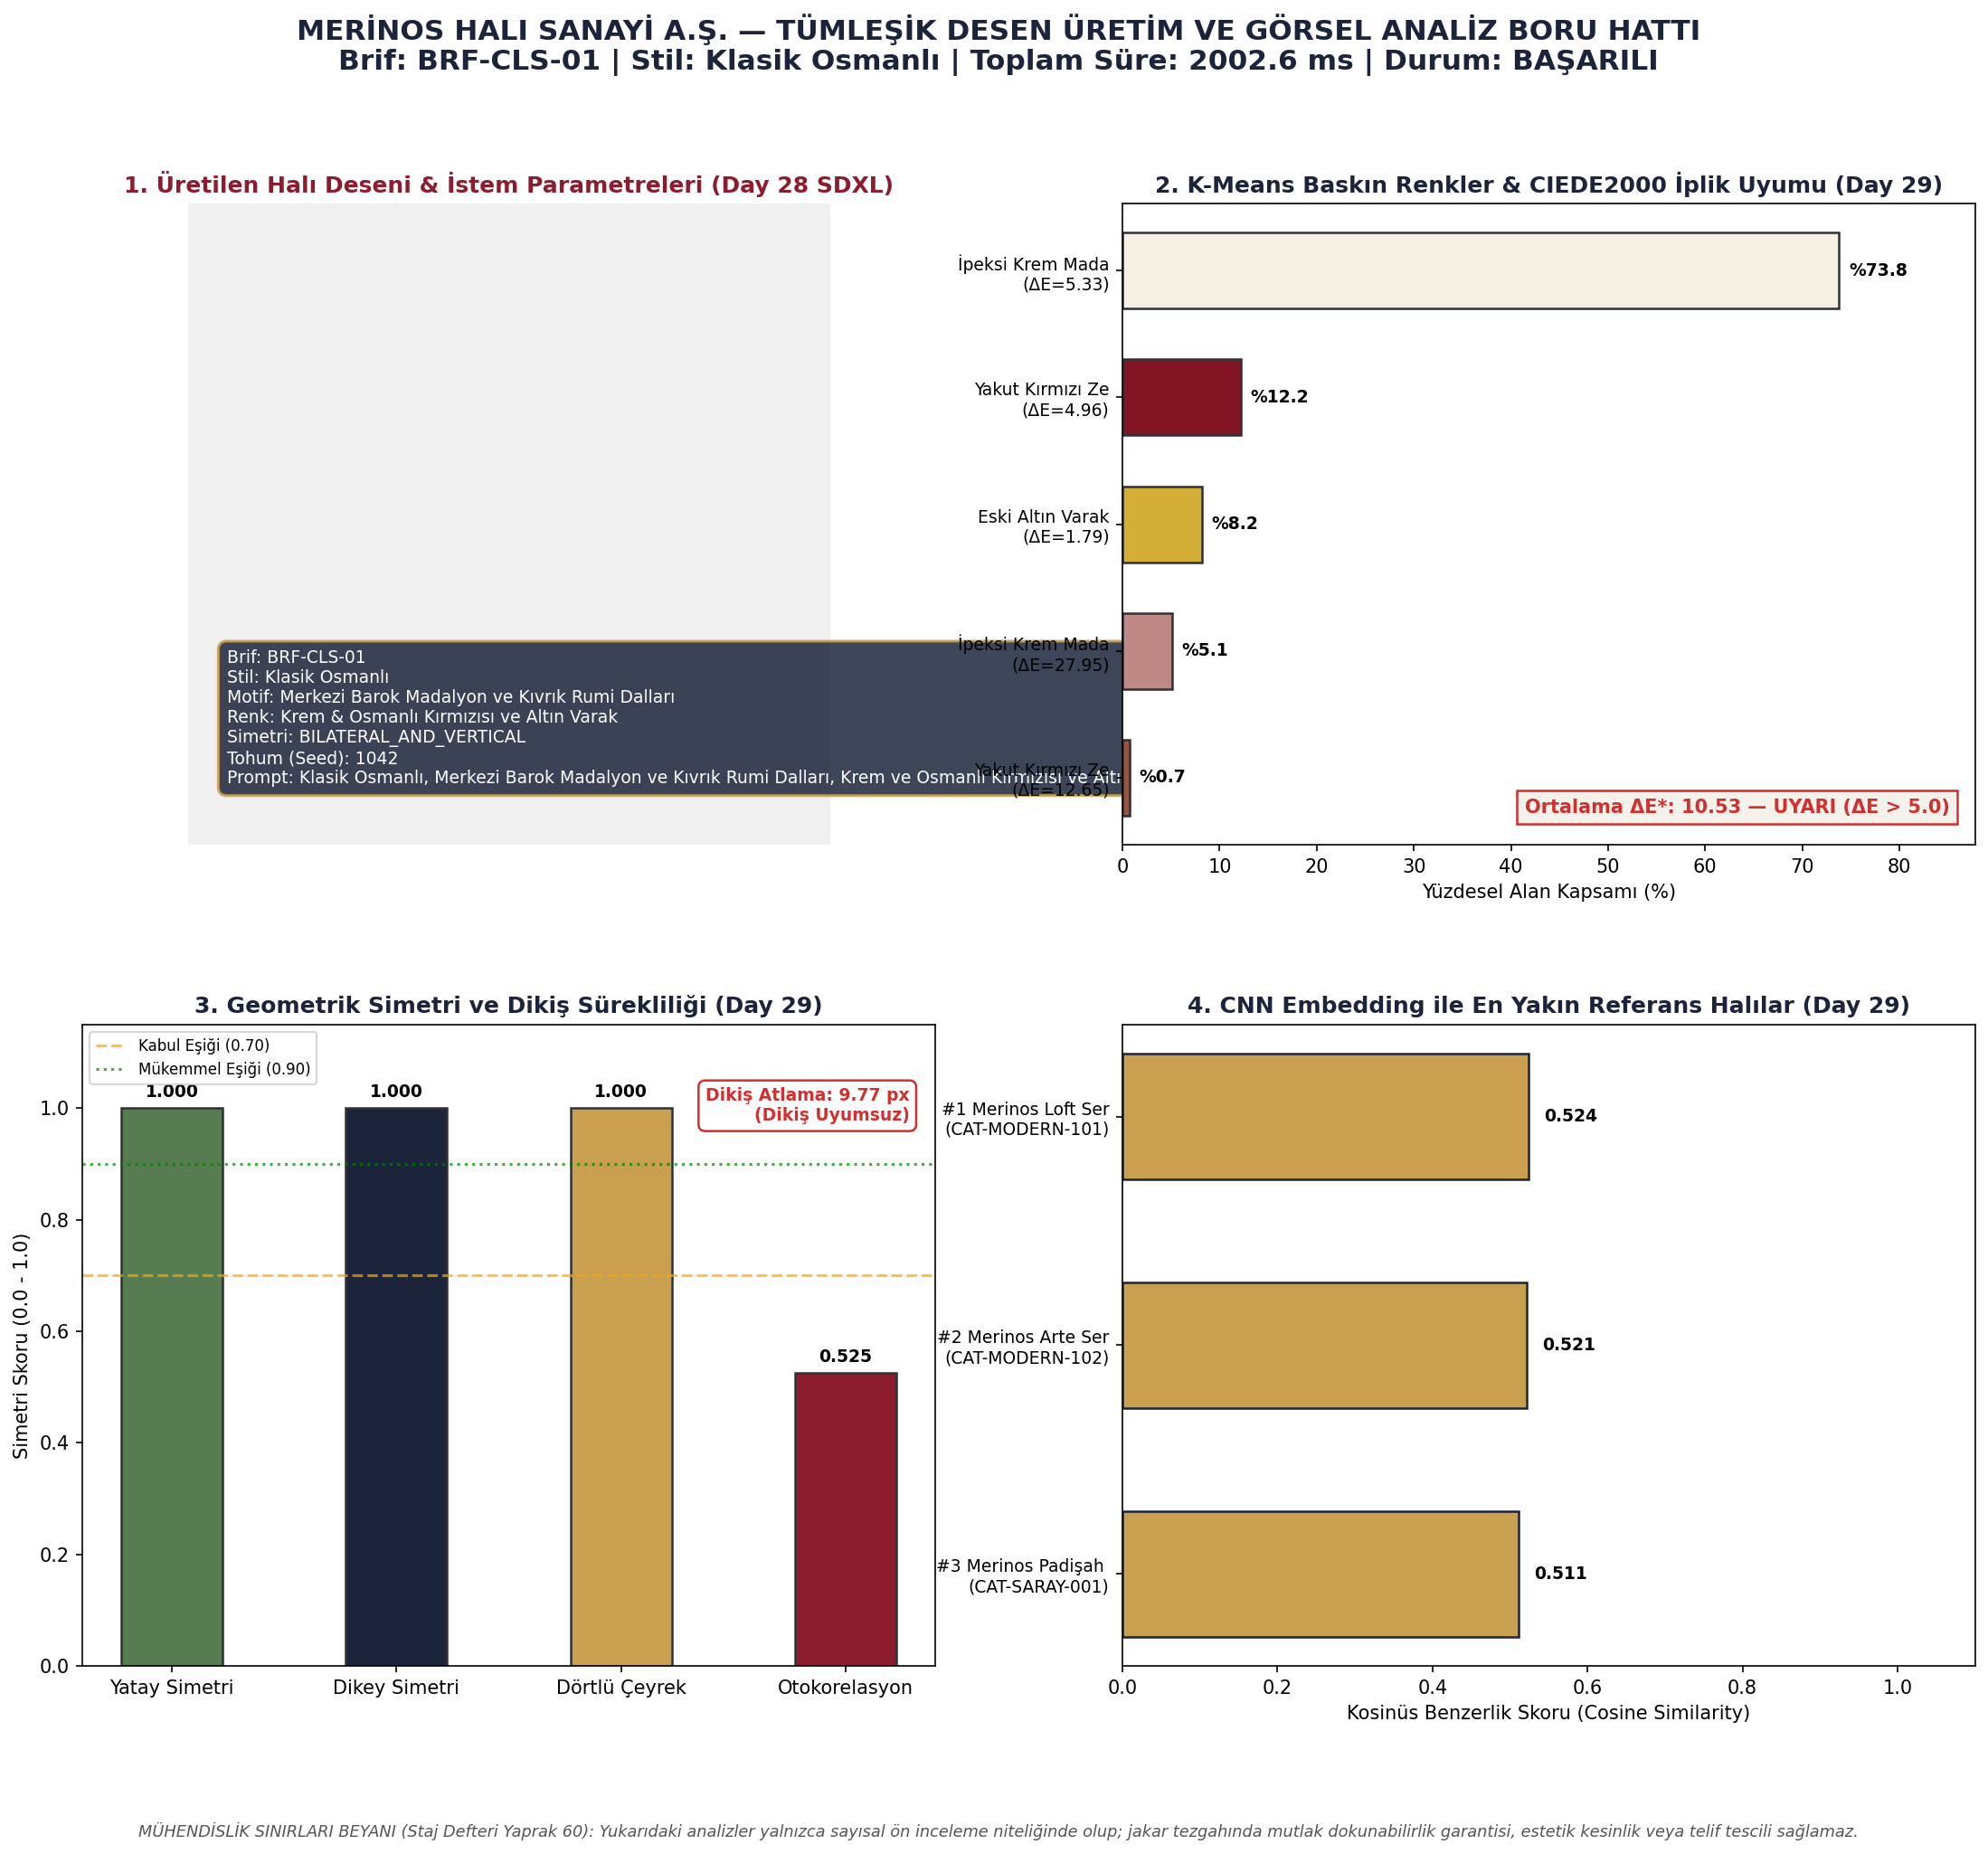

In [9]:
viz = CarpetPipelineVisualizer(dpi=150)
panel_path = viz.create_master_diagnostic_panel(output)
print(f"✅ 300 DPI Master Teşhis Paneli Kaydedildi: {panel_path}")

# Notebook içinde görselleştir
panel_img = cv2.imread(str(panel_path))
if panel_img is not None:
    panel_rgb = cv2.cvtColor(panel_img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(16, 12), dpi=100)
    plt.imshow(panel_rgb)
    plt.axis("off")
    plt.title("Merinos Day 30: Tümleşik Halı Üretim & Görsel Teşhis Kokpiti (Yaprak 59-60)", fontsize=14, fontweight="bold")
    plt.show()

### 9. Sonuç ve Faz 5 Değerlendirmesi
Bu çalışma ile **Faz 5 (Üretken Yapay Zekâ ve Görsel Analitik)** başarıyla tamamlanmıştır:
- **Day 28:** Tasarım istekleri alanlara ayrılarak SDXL difüzyon modelinde kontrollü tohumlama ve tek değişkenli prompt karşılaştırmaları yapıldı.
- **Day 29:** Üretilen görseller K-Means, CIELAB $\Delta E^*$, geometrik ayna simetrisi, dikiş sürekliliği ve pretrained CNN embedding ile sayısallaştırıldı.
- **Day 30:** Üretim ve analiz adımları tek bir boru hattında (`IntegratedCarpetPipeline`) birleştirildi; FastAPI web kokpiti, Yaprak 60 hata durumları ve 4 teknik sınır başarıyla belgelendi.

Sistem artık **Faz 6 (Kurumsal RAG, İSG Guardrails, Edge AI & Master Platform: Gün 31-40)** için hazırdır.